In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
df = pd.read_csv('../data/sales.csv')
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [90]:
df.isnull().sum()
df.dropna(inplace=True)

In [91]:
df['sales'].dtype

dtype('O')

In [92]:
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

In [93]:
df = df.dropna(subset=['sales'])

In [94]:
df['sales'].head(10)

0    408.0
1    120.0
2     66.0
3     45.0
4    114.0
5     55.0
6    314.0
7    276.0
8    912.0
9    667.0
Name: sales, dtype: float64

In [95]:
df = df.dropna(subset=['sales'])

In [96]:
df['sales'].dtype

dtype('float64')

In [97]:
import os

# make sure images folder exists
os.makedirs('../images', exist_ok=True)

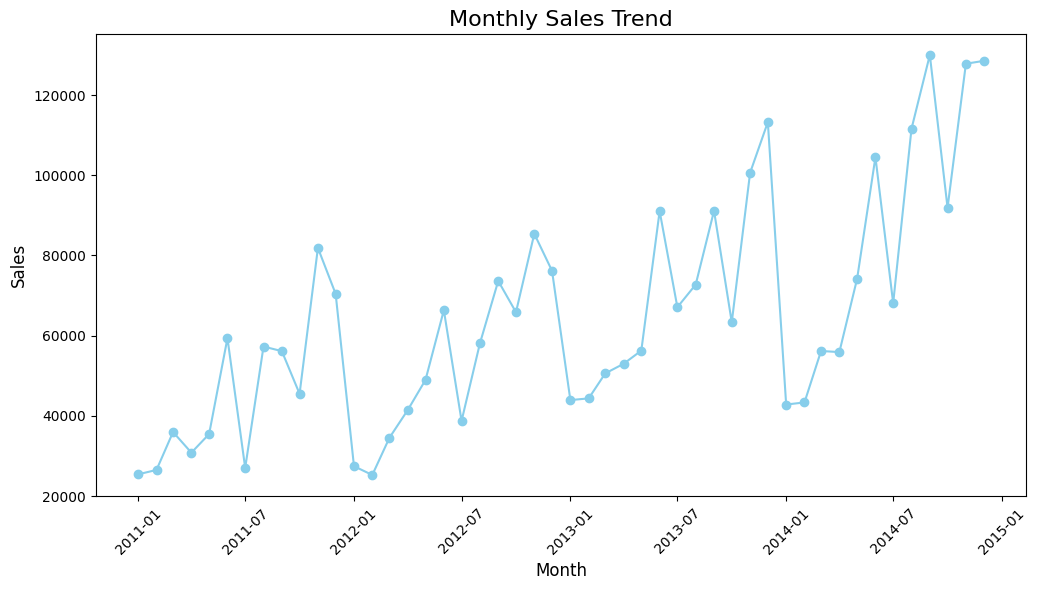

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# create folder if it doesn't exist
os.makedirs('../images', exist_ok=True)

# load and clean data
df = pd.read_csv('../data/sales.csv')
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['order_date'])
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
df = df.dropna(subset=['sales'])

# group by month and convert index to datetime for plotting
sales_trend = df.groupby(df['order_date'].dt.to_period('M'))['sales'].sum()
sales_trend.index = sales_trend.index.to_timestamp()  # crucial fix

# create a new figure
fig, ax = plt.subplots(figsize=(12,6))

# plot manually
ax.plot(sales_trend.index, sales_trend.values, marker='o', color='skyblue')
ax.set_title("Monthly Sales Trend", fontsize=16)
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Sales", fontsize=12)
plt.xticks(rotation=45)

# save figure — THIS WILL WORK
fig.savefig('../images/sales_trend.png', bbox_inches='tight')

# show figure
plt.show()

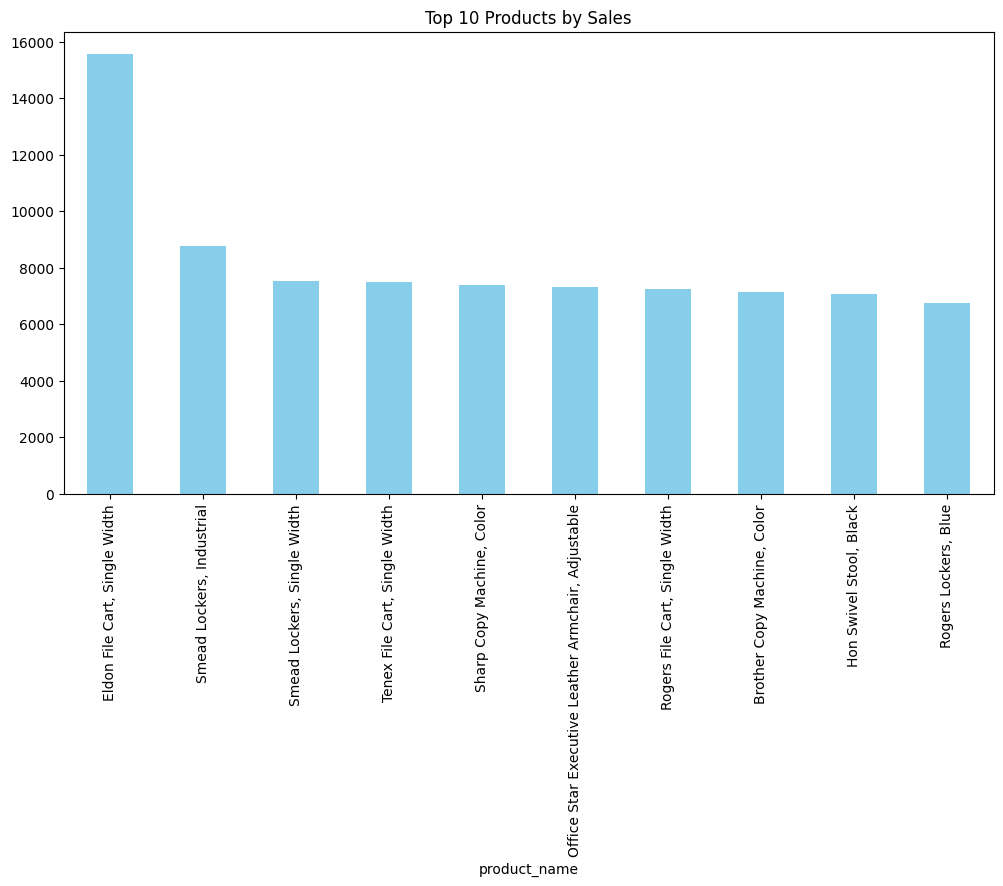

In [99]:
import matplotlib.pyplot as plt
import os

# make sure images folder exists (already done, safe to call again)
os.makedirs('../images', exist_ok=True)

# group by product and sum sales
top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)

# plot bar chart
top_products.plot(kind='bar', figsize=(12,6), title="Top 10 Products by Sales", color='skyblue')

# save chart
plt.savefig('../images/top_products.png')

# show chart
plt.show()

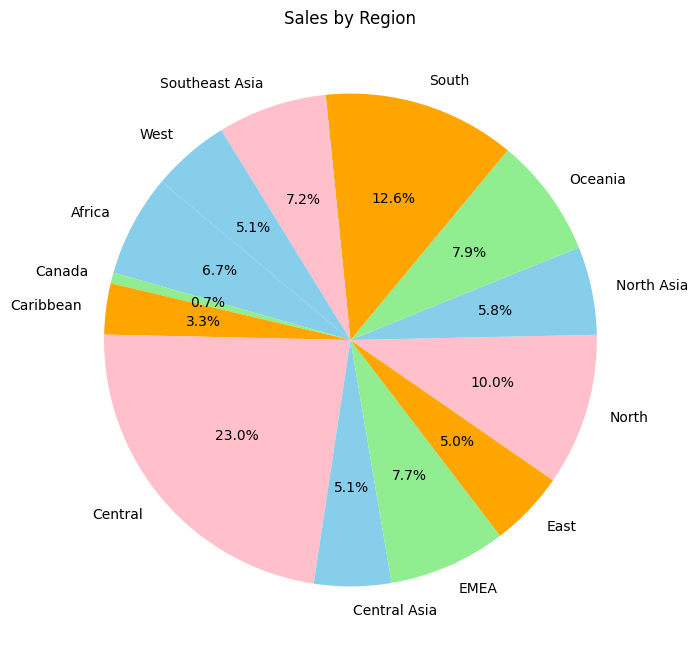

In [100]:
import matplotlib.pyplot as plt
import os

# ensure images folder exists
os.makedirs('../images', exist_ok=True)

# group by region and sum sales
region_sales = df.groupby('region')['sales'].sum()

# plot pie chart
plt.figure(figsize=(8,8))
plt.pie(region_sales, labels=region_sales.index, autopct='%1.1f%%', startangle=140, colors=['skyblue','lightgreen','orange','pink'])
plt.title("Sales by Region")

# save chart
plt.savefig('../images/region_sales.png')

# show chart
plt.show()

In [101]:
# convert to datetime, force errors to NaT (missing)
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True, errors='coerce')

# drop rows where conversion failed
df = df.dropna(subset=['order_date'])

# check result
df['order_date'].head()
df['order_date'].dtype

dtype('<M8[ns]')

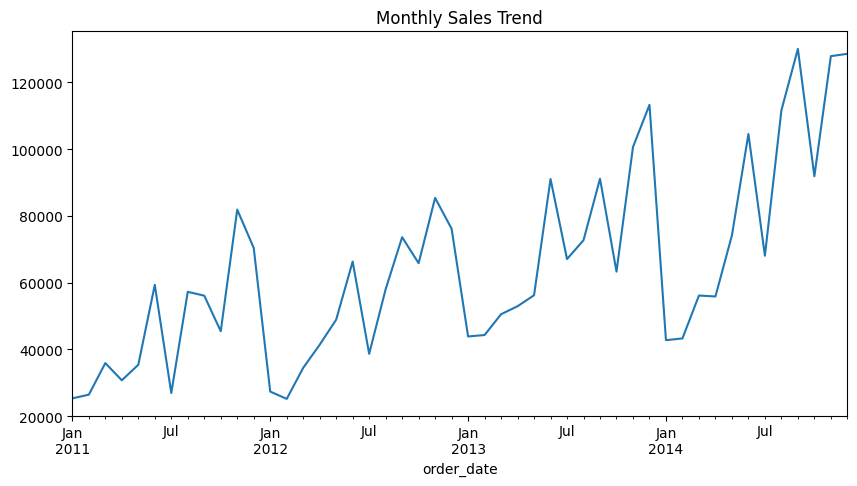

In [102]:
import matplotlib.pyplot as plt
import os

# ensure images folder exists
os.makedirs('../images', exist_ok=True)

# group by month
sales_trend = df.groupby(df['order_date'].dt.to_period('M'))['sales'].sum()

# create figure & axis explicitly
fig, ax = plt.subplots(figsize=(10,5))

# plot on that axis
sales_trend.plot(ax=ax, title="Monthly Sales Trend")

# save this exact figure
fig.savefig('../images/sales_trend.png')

# show plot
plt.show()

In [103]:
df.dtypes

order_id                  object
order_date        datetime64[ns]
ship_date                 object
ship_mode                 object
customer_name             object
segment                   object
state                     object
country                   object
market                    object
region                    object
product_id                object
category                  object
sub_category              object
product_name              object
sales                    float64
quantity                   int64
discount                 float64
profit                   float64
shipping_cost            float64
order_priority            object
year                       int64
dtype: object

In [104]:
import pandas as pd
import os

# 1️⃣ Load data
df = pd.read_csv('../data/sales.csv')

# 2️⃣ Clean data
df.dropna(inplace=True)  # drop nulls
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
df = df.dropna(subset=['sales'])
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['order_date'])

# 3️⃣ Verify
print(df.dtypes)
print(df.head())

# 4️⃣ Save cleaned CSV (this is where you run it)
os.makedirs('../data', exist_ok=True)
df.to_csv('../data/sales_cleaned.csv', index=False)
print("Cleaned data saved successfully!")

order_id                  object
order_date        datetime64[ns]
ship_date                 object
ship_mode                 object
customer_name             object
segment                   object
state                     object
country                   object
market                    object
region                    object
product_id                object
category                  object
sub_category              object
product_name              object
sales                    float64
quantity                   int64
discount                 float64
profit                   float64
shipping_cost            float64
order_priority            object
year                       int64
dtype: object
          order_id order_date ship_date       ship_mode    customer_name  \
0     AG-2011-2040 2011-01-01  6/1/2011  Standard Class  Toby Braunhardt   
1    IN-2011-47883 2011-01-01  8/1/2011  Standard Class      Joseph Holt   
2     HU-2011-1220 2011-01-01  5/1/2011    Second Class    Annie 